In [61]:
from sklearn.model_selection import train_test_split
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import zipfile

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F

In [62]:
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 42
torch.random.manual_seed(seed)

epochs = 5
batch_size = 4
lr = 1e-3

EVALUATION = False
root_dir = "/home/stefan/ioai-prep/kits/ioai-2025/radar" if not EVALUATION else "/bohr/train-4gug/v2/training_set"

# Data preparation

In [63]:
class CustomDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform
        self.file_names = [os.path.basename(path) for path in file_paths]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        data = torch.load(self.file_paths[idx], weights_only=True)
        
        images = data[:6]  
        labels = data[6]           
        
        images = images.float()  
        labels = labels.long()

        if self.transform:
            images = self.transform(images)
            labels = self.transform(labels)
        
        return images, labels

def generate_file_paths(base_path):
    file_paths = []
    for frame in os.listdir(base_path):
        frame_path = os.path.join(base_path, frame)
        if frame_path.endswith('.mat.pt'):
            file_paths.append(frame_path)
    return [path for path in file_paths if os.path.exists(path)]

def load_data(base_path, test_size=0.4):
    file_paths = generate_file_paths(base_path)
    
    train_paths, test_paths = train_test_split(file_paths, test_size=test_size, random_state=42)
    val_paths, test_paths = train_test_split(test_paths, test_size=test_size/2, random_state=42)
    
    train_dataset = CustomDataset(file_paths=train_paths)
    test_dataset = CustomDataset(file_paths=test_paths)
    val_dataset = CustomDataset(file_paths=val_paths)
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        drop_last=True
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False
    )
    
    return train_loader, test_loader, val_loader


In [64]:
train_loader, test_loader, val_loader = load_data(root_dir)

In [65]:
# sanity check
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([4, 6, 50, 181]), torch.Size([4, 50, 181])]

# Model

In [66]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class MyModel(nn.Module):
    def __init__(self, in_channels=6, out_channels=2, features=[32, 64, 128]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        # Downsampling path
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Upsampling path
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        # Final classifier
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

        # Max pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip_connections = []

        # Down path
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Up path
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # Transposed conv
            skip_connection = skip_connections[idx // 2]

            # Padding if needed due to odd size
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])

            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](x)

        return self.final_conv(x)

In [67]:
model = MyModel().to(device)

model(batch[0].to(device)).shape

torch.Size([4, 2, 50, 181])

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight  # optional class weights (e.g., torch.tensor([1.0, 1500.0]))

    def forward(self, inputs, targets):
        # inputs: (N, 2, H, W) raw logits
        # targets: (N, H, W)
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Training

In [69]:
train_losses, test_losses = [], []

optimizer = AdamW(model.parameters(), lr=lr)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader), eta_min=1e-6)

weights = torch.tensor([1.0, 5000.0], device=device)
criterion = FocalLoss(weight=weights)

In [70]:
for epoch in range(1, 1+epochs):
    model.train()
    epoch_loss = 0.0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        # forward pass
        outputs = model(images)
        outputs = outputs.view(outputs.size(0), outputs.size(1), -1)  # [B, C, H*W]
        labels = labels.view(labels.size(0), -1)  # [B, H*W]
        loss = criterion(outputs, labels)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        # stats
        epoch_loss += loss.item()
        train_losses.append(loss.item())

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            outputs = outputs.view(outputs.size(0), outputs.size(1), -1)
            labels = labels.view(labels.size(0), -1)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            test_losses.append(loss.item())

    avg_train_loss = epoch_loss / len(train_loader)
    avg_test_loss = test_loss / len(test_loader)
    print(f"Epoch {epoch}; train_loss={avg_train_loss:.4f}; test_loss={avg_test_loss:.4f}")

  0%|          | 0/270 [00:00<?, ?it/s]

100%|██████████| 36/36 [00:00<00:00, 178.37it/s]


Epoch 1; train_loss=0.2266; test_loss=0.1487


100%|██████████| 36/36 [00:00<00:00, 172.47it/s]


Epoch 2; train_loss=0.1504; test_loss=0.1219


...

Epoch 3; train_loss=0.0715; test_loss=0.0779


100%|██████████| 36/36 [00:00<00:00, 155.90it/s]


Epoch 4; train_loss=0.0464; test_loss=0.0733


100%|██████████| 36/36 [00:00<00:00, 173.07it/s]

Epoch 5; train_loss=0.0371; test_loss=0.0681


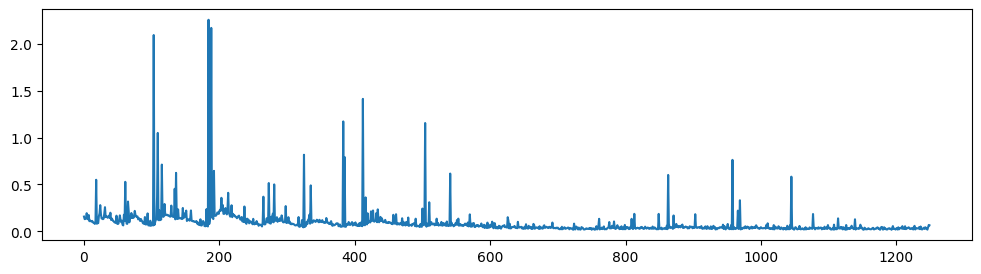

In [71]:
plt.figure(figsize=(12, 3))
plt.plot(train_losses[100:], label='train')

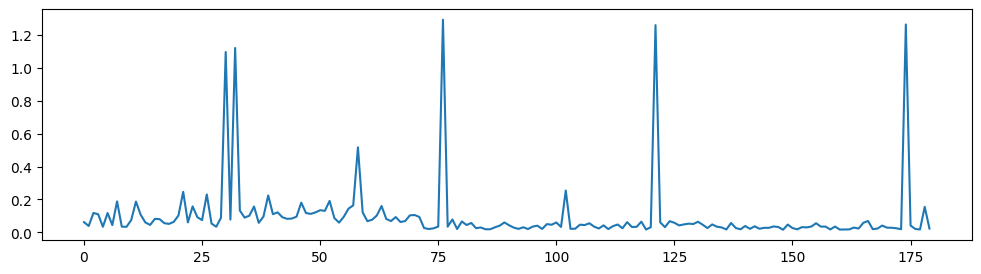

In [72]:
plt.figure(figsize=(12, 3))
plt.plot(test_losses, label='val')

# Evaluation

In [73]:
def cal_accuracy(model, test_loader, bonus=1.0):
    model.eval()
    total_score = 0
    total_theo = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.cuda() if torch.cuda.is_available() else images
            labels = labels.cuda() if torch.cuda.is_available() else labels

            outputs = model(images)
            outputs = torch.argmax(outputs, dim=1)

            equal_mask = outputs == labels  # correctly predicted masks
            neg_one_mask = labels == 0      # Mask of background categories

            # Calculate the score
            score_neg_one = (equal_mask & neg_one_mask).sum() * 1  # Background category score
            score_other = (equal_mask & ~neg_one_mask).sum() * bonus  # Target category score
            score_theo = neg_one_mask.sum() * 1 + (~neg_one_mask).sum() * bonus  # Full marks in theory

            total_score += score_neg_one + score_other
            total_theo += score_theo

    score = total_score.item() / total_theo.item()
    return score

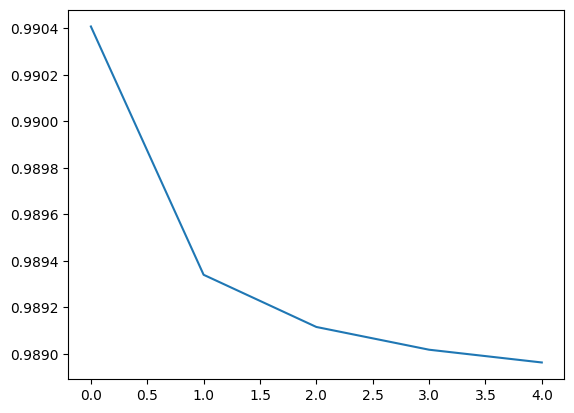

In [74]:
import numpy as np
i = np.linspace(100, 10000, 5)
c = [cal_accuracy(model, val_loader, j) for j in i]
plt.plot(c)

In [75]:
cal_accuracy(model, val_loader, 3500), cal_accuracy(model, train_loader)

(0.9892288567388122, 0.9901034376918355)

In [76]:
# actually gets 0.9968 on Leaderboard A

# Submission

In [77]:
model_code = """  
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class MyModel(nn.Module):
    def __init__(self, in_channels=6, out_channels=2, features=[32, 64, 128]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        # Downsampling path
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Upsampling path
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature*2, feature))

        # Final classifier
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

        # Max pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip_connections = []

        # Down path
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Up path
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # Transposed conv
            skip_connection = skip_connections[idx // 2]

            # Padding if needed due to odd size
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])

            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](x)

        return self.final_conv(x)
"""
# Write code to file
with open('submission_model.py', 'w',encoding="utf-8") as f:
    f.write(model_code)
print("submission_model.py file has been generated.")

submission_model.py file has been generated.


In [78]:
# Save the parameters of the model
torch.save(model.state_dict(), 'submission_dic.pth')
print("submission_dic.pth file has been saved.")

submission_dic.pth file has been saved.


In [79]:
# Define the files to zip and the zip file name.
files_to_zip = ['submission_model.py', 'submission_dic.pth']
zip_filename = 'submission.zip'

# Create a zip file
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        # Add the file to the zip fil
        zipf.write(file, os.path.basename(file))

print(f'{zip_filename} Created successfully!')

submission.zip Created successfully!
